# Applying Bayesian Inference Techniques on M31 Andromeda Data
### Bryan Milosevic-Hill
>I do not own the rights to any of the data used in this notebook. All code is authored by me, modified to apply to M31 data set. I would like to credit Dr Sean Tulin for creating the assignment that inspired this notebook.  

---
Much of my PHYS 2030 professor's own research is on dark matter, and as such he sculpted a lot of the course content to include nuanced lessons regarding his areas of interest. I found the Bayesian inference we did in class quite interesting and wanted to apply these techniques on a galaxy that I knew off the top of my head, instead of some ideal candidate dwarf galaxy (in class we used NGC2366).

This analysis uses a Markov Chain Monte Carlo (MCMC) simulation to fit three parameters of a dark matter enclosed mass model to the rotation curve of our neighbouring galaxy Andromeda. The rotation curve data is from a deep, full-disk 21-cm HI survey of M31 using the Westerbork and Green Bank radio telescopes ([Corbelli et al. 2010](https://arxiv.org/abs/0912.4133)).

I wanted to see if inferring a core vs cusp interpretation was as cut and dry for a galaxy that is less of an ideal candidate for this sort of analysis, as it has large masses of stars and other baryonic matter that our single-component model cannot separate from the dark matter contribution.

---

## The Model

The enclosed mass function accommodates both core and cusp profiles:

$$M(r) = \frac{M_{\rm tot} \, r^{3 - n}}{(r + R_s)^{3 - n}}$$

where $M_{\rm tot}$ is the total mass, $R_s$ is the scale radius, and $n$ interpolates between a core ($n = 0$, where $M(r) \propto r^3$) and a cusp ($n = 1$, where $M(r) \propto r^2$).

The circular velocity as a function of radius is:

$$v(r) = \sqrt{\frac{G \, M_{\rm tot} \, r^{2 - n}}{(r + R_s)^{3 - n}}}$$

We fit in log-space: $x = \log_{10}(R_s)$, $y = \log_{10}(M_{\rm tot})$, and sample $n$ directly. The target PDF is:

$$P(x, y, n) = \begin{cases} e^{-\frac{1}{2} \chi^2(x,y,n)} & n \geq 0 \\ 0 & n < 0 \end{cases}$$

>This model was proposed in class

## Data

Rotation curve data for M31 (Andromeda) from a 21-cm HI survey (Corbelli et al. 2010). Measurements are the circular velocity $v$ (km/s) at various radial positions $r$ (kpc) from the galactic center, spanning 8.5 to 36.5 kpc.

<img src="https://i.imgur.com/BNyiLgq.png" width="30%"> [source](https://arxiv.org/pdf/0912.4133)

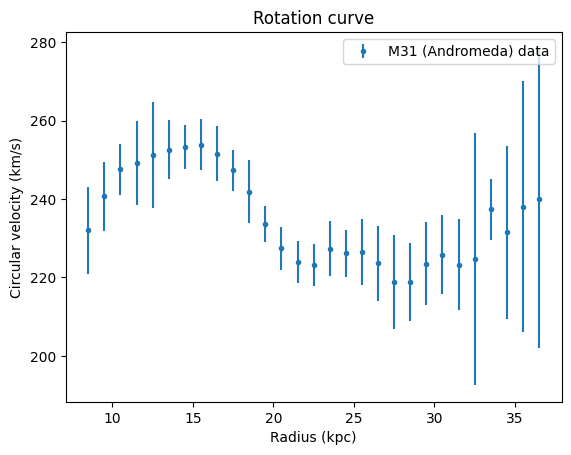

In [1]:
import numpy as np
import matplotlib.pyplot as plt

G = 4.3e-6  # km^2/s^2 Msun^-1 kpc

# Corbelli et al. 2010, Table 1 — M31 (Andromeda) rotation curve
# 21-cm HI survey, Westerbork + Green Bank Telescopes

radius = np.array([8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5,
                   18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5,
                   28.5, 29.5, 30.5, 31.5, 32.5, 33.5, 34.5, 35.5, 36.5])

mu = np.array([232.0, 240.7, 247.6, 249.1, 251.2, 252.6, 253.2, 253.8, 251.6, 247.3,
               241.9, 233.6, 227.4, 224.0, 223.2, 227.3, 226.2, 226.4, 223.6, 218.9,
               218.8, 223.5, 225.8, 223.2, 224.7, 237.4, 231.5, 238.0, 240.1])

sigma = np.array([11.0, 8.8, 6.5, 10.7, 13.5, 7.6, 5.6, 6.5, 7.1, 5.2,
                  8.1, 4.6, 5.5, 5.3, 5.4, 7.0, 6.0, 8.4, 9.5, 12.0,
                  9.9, 10.6, 10.1, 11.6, 32.1, 7.8, 22.1, 32.0, 38.2])

plt.errorbar(radius, mu, yerr=sigma, fmt='.', label='M31 (Andromeda) data')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular velocity (km/s)')
plt.title('Rotation curve')
plt.legend()
plt.show()

## Model and Target PDF

In [2]:
def vOfR(r, Mtot, Rs, n):
    exp = 3 - n
    return np.sqrt(G * Mtot * r**(2.0 - n) / (r + Rs)**exp)

def chiSq(x, y, n):
    vPred = vOfR(radius, 10**y, 10**x, n)
    return np.sum(((vPred - mu) / sigma) ** 2)

def P(x, y, n):
    if n < 0:
        return 0.0
    return np.exp(-0.5 * chiSq(x, y, n))

## MCMC Sampling via Metropolis Algorithm

We generate $N = 10^6$ samples for $(x, y, n)$ using the Metropolis algorithm with independent univariate normal proposal distributions for each parameter.

In [3]:
N = 10**6
xNot, yNot, nNot = 1.0, 11.8, 0.3
sX, sY, sN = 0.01, 0.01, 0.05
xSamples = [xNot]
ySamples = [yNot]
nSamples = [nNot]

xOld, yOld, nOld = xNot, yNot, nNot
pOld = P(xOld, yOld, nOld)
accept = 0
for i in range(N - 1):
        xNew = np.random.normal(xOld, sX)
        yNew = np.random.normal(yOld, sY)
        nNew = np.random.normal(nOld, sN)

        pNew = P(xNew, yNew, nNew)

        if (pOld == 0):
            A = 1.0
        else:
            A = pNew / pOld

        if ((A > 1) or (np.random.rand() < A)):
            xSamples.append(xNew)
            ySamples.append(yNew)
            nSamples.append(nNew)
            xOld, yOld, nOld = xNew, yNew, nNew
            pOld = pNew
            accept += 1

        else:
            xSamples.append(xOld)
            ySamples.append(yOld)
            nSamples.append(nOld)

print("Acceptance fraction: %.4f" % (accept / N))

Acceptance fraction: 0.3054


## Chain Convergence

Plotting the first 1000 samples of each chain to verify there is no burn-in period.

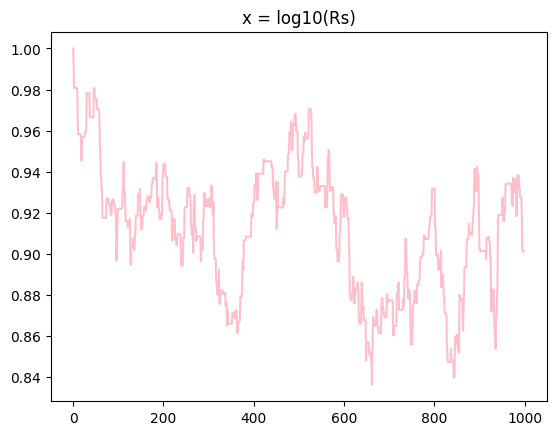

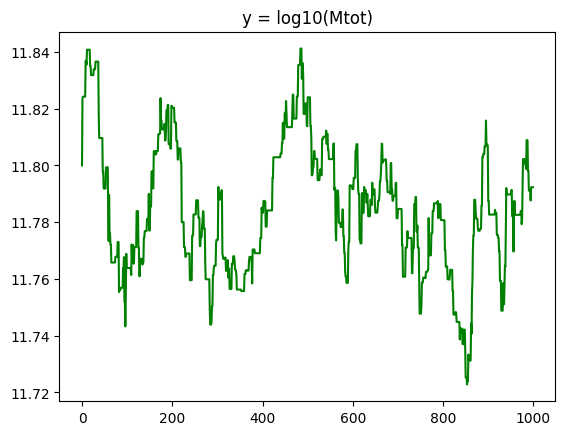

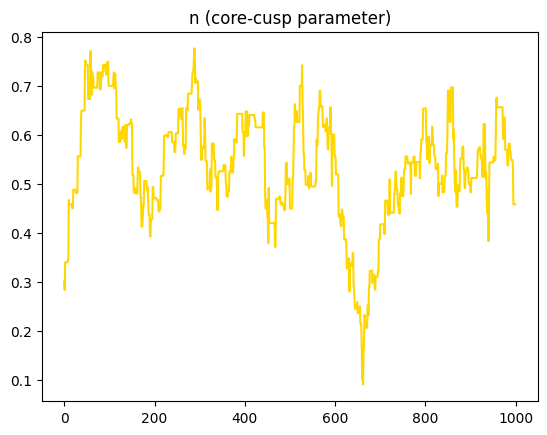

In [5]:
plt.title("x = log10(Rs)")
plt.plot(xSamples[:1000], color='pink')
plt.show()

plt.title("y = log10(Mtot)")
plt.plot(ySamples[:1000], color='green')
plt.show()

plt.title("n (core-cusp parameter)")
plt.plot(nSamples[:1000], color='gold')
plt.show()

## Results

In [4]:
centN = np.mean(nSamples)
errN  = np.std(nSamples)

mTotSamples = 10**np.array(ySamples)
centMtot = np.mean(mTotSamples)
errMtot  = np.std(mTotSamples)

print("centN = %.3f || errN = %.3f" % (centN, errN))
print("centMtot = %.3e || errMtot = %.3e" % (centMtot, errMtot))

centN = 1.158 || errN = 0.583
centMtot = 7.221e+11 || errMtot = 1.809e+11


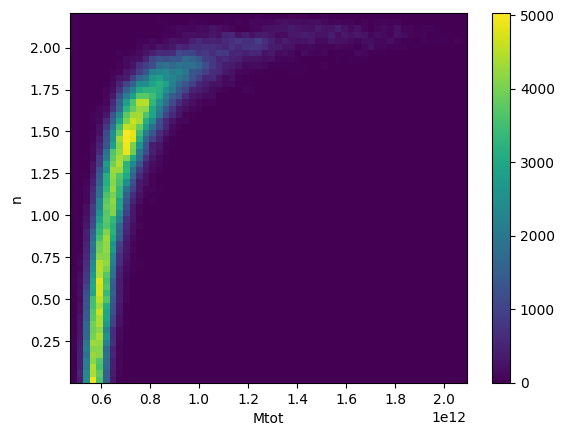

In [6]:
plt.hist2d(mTotSamples, nSamples, bins=60)
plt.xlabel("Mtot")
plt.ylabel("n")
plt.colorbar()
plt.show()

## Conclusion

In class, the NGC2366 dataset from a dark-matter-dominated dwarf galaxy yielded n close to 0. This was strong evidence to suggest a core interpretation. For M31, the MCMC centres near `n ≈ 1.105` but with a large uncertainty (+/-0.583). I imagine this uncertainty comes from the large amount of non-dark-matter mass in the galaxy: stars, gas, and other massive celestial bodies. As expected, this model cannot discern what contributions come from these large mass objects and what comes from dark matter.

I'm sure there are more nuanced ways to approach this problem, and [Corbelli et al. (2010)](https://arxiv.org/pdf/0912.4133) do exactly that by breaking the rotation curve into separate bulge, disk, gas, and dark halo components. That is obviously a much more in-depth model than the single-profile we explored in class. Still, it was interesting to see how the same MCMC technique that gave a clean answer for a dwarf galaxy starts to struggle when applied to a massive spiral galaxy.